In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(Path("../data/Loan_Data.csv"))
print("shape: ", df.shape)
print("\n column name:")
print(df.columns.tolist())
print("\nfirst few data")
print(df.head(10).to_string())
print("\nDB info:")
print(df.info)
print("\n missing values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())

shape:  (614, 13)

 column name:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

first few data
    Loan_ID Gender Married Dependents     Education Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History Property_Area Loan_Status
0  LP001002   Male      No          0      Graduate            No             5849                0.0         NaN             360.0             1.0         Urban           Y
1  LP001003   Male     Yes          1      Graduate            No             4583             1508.0       128.0             360.0             1.0         Rural           N
2  LP001005   Male     Yes          0      Graduate           Yes             3000                0.0        66.0             360.0             1.0         Urban           Y
3  LP001006   Male     Yes          0  Not Graduate   


 ----------Loan status analysis---------------

Loan Status Count:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Loan Status Percentage:
Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64


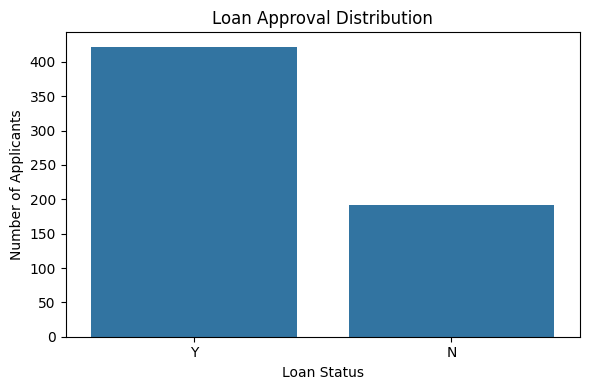

In [5]:
print("\n ----------Loan status analysis---------------")
print("\nLoan Status Count:")
print(df["Loan_Status"].value_counts())
print("\nLoan Status Percentage:")
print(
    df["Loan_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Loan_Status"
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()


 ---------------applicants income analysis--------------- 
count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64


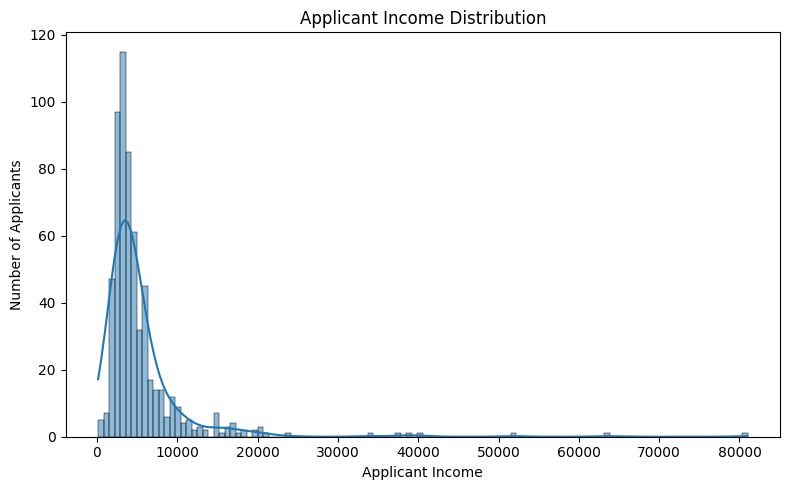


 -----------loan amount analysis------------------------
count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64


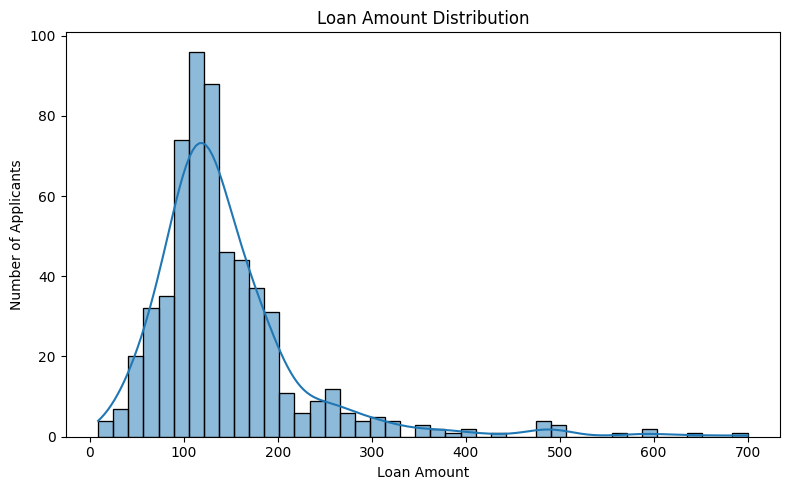


 ------------------coappliant income analysis--------------------
count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64


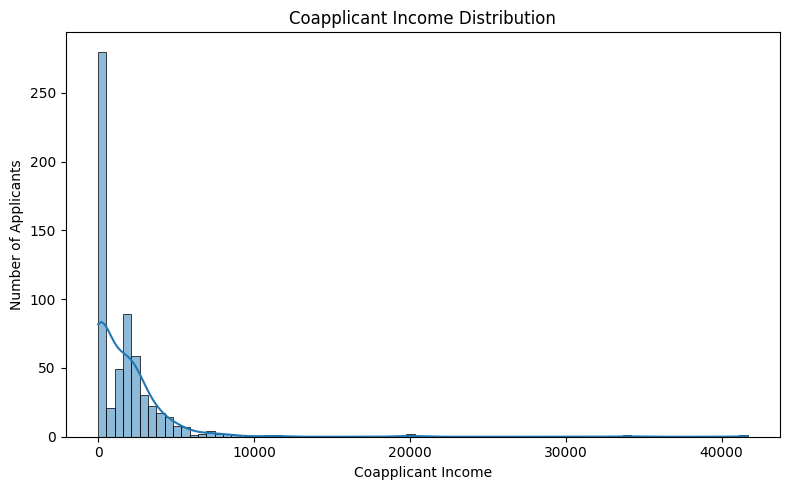


-------------- Loan amount term analysis -------------
count    600.00000
mean     342.00000
std       65.12041
min       12.00000
25%      360.00000
50%      360.00000
75%      360.00000
max      480.00000
Name: Loan_Amount_Term, dtype: float64

Loan Amount Term Frequency:
Loan_Amount_Term
12.0       1
36.0       2
60.0       2
84.0       4
120.0      3
180.0     44
240.0      4
300.0     13
360.0    512
480.0     15
Name: count, dtype: int64


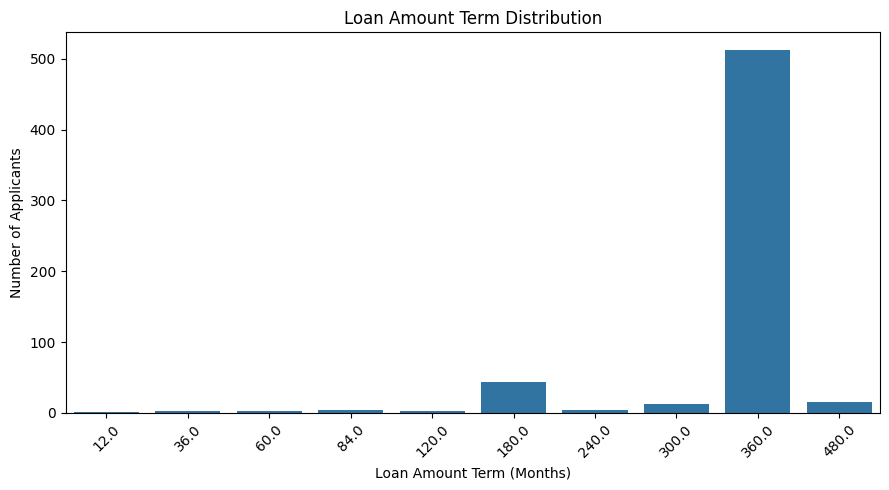

In [6]:
print("\n ---------------applicants income analysis--------------- ")
print(df["ApplicantIncome"].describe())
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="ApplicantIncome",
    kde=True
)

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()
print("\n -----------loan amount analysis------------------------")
print(df["LoanAmount"].describe())
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="LoanAmount",
    kde=True
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()
print("\n ------------------coappliant income analysis--------------------")
print(df["CoapplicantIncome"].describe())
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="CoapplicantIncome",
    kde=True
)

plt.title("Coapplicant Income Distribution")
plt.xlabel("Coapplicant Income")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()
print("\n-------------- Loan amount term analysis -------------")
print(df["Loan_Amount_Term"].describe())
print("\nLoan Amount Term Frequency:")
print(df["Loan_Amount_Term"].value_counts().sort_index())
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Loan_Amount_Term"
)

plt.title("Loan Amount Term Distribution")
plt.xlabel("Loan Amount Term (Months)")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


------------- credit history analysis ----------------
Credit History Frequency:
Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64

Credit History vs Loan Status:
Loan_Status      N    Y
Credit_History         
0.0             82    7
1.0             97  378
NaN             13   37

Loan Approval Percentage by Credit History:
Loan_Status         N      Y
Credit_History              
0.0             92.13   7.87
1.0             20.42  79.58
NaN             26.00  74.00


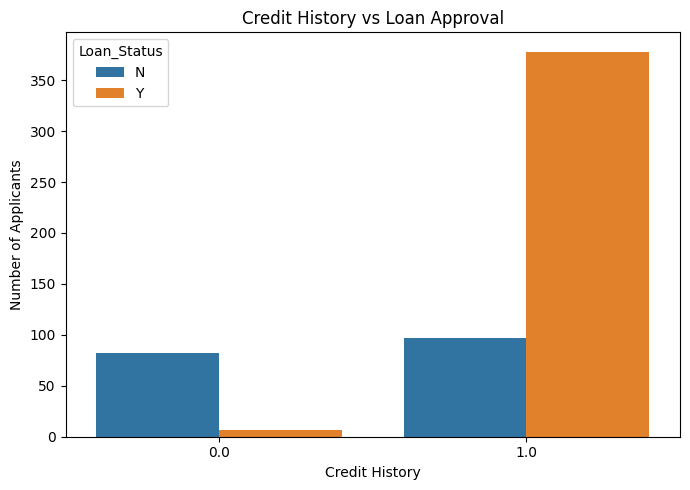


 --------------------education vs loan status--------------------
Loan_Status     N    Y
Education             
Graduate      140  340
Not Graduate   52   82

Loan Approval Percentage by Education:
Loan_Status       N      Y
Education                 
Graduate      29.17  70.83
Not Graduate  38.81  61.19


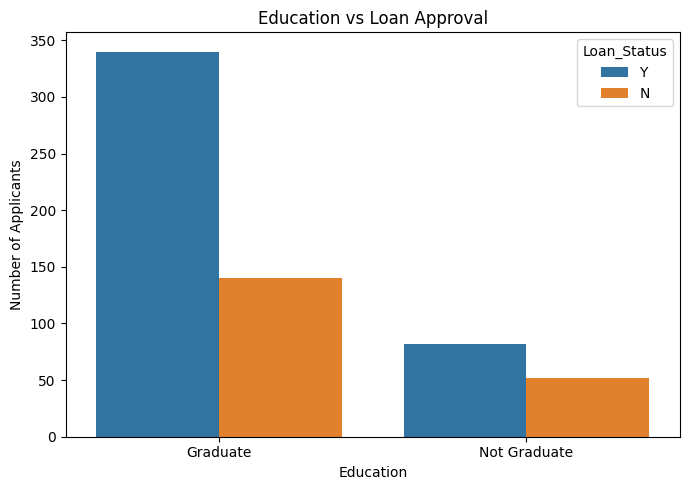

In [7]:
print("\n------------- credit history analysis ----------------")
print("Credit History Frequency:")
print(df["Credit_History"].value_counts(dropna=False))
print("\nCredit History vs Loan Status:")

print(
    pd.crosstab(
        df["Credit_History"],
        df["Loan_Status"],
        dropna=False
    )
)
print("\nLoan Approval Percentage by Credit History:")
print(
    pd.crosstab(
        df["Credit_History"],
        df["Loan_Status"],
        normalize="index",
        dropna=False
    ).mul(100).round(2)
)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Credit History vs Loan Approval")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()
print("\n --------------------education vs loan status--------------------")
print(
    pd.crosstab(
        df["Education"],
        df["Loan_Status"]
    )
)
print("\nLoan Approval Percentage by Education:")
print(
    pd.crosstab(
        df["Education"],
        df["Loan_Status"],
        normalize="index"
    ).mul(100).round(2)
)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Status"
)

plt.title("Education vs Loan Approval")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()


----------- property area vs loan status-----------------
Loan_Status     N    Y
Property_Area         
Rural          69  110
Semiurban      54  179
Urban          69  133

Loan Approval Percentage by Property Area:
Loan_Status        N      Y
Property_Area              
Rural          38.55  61.45
Semiurban      23.18  76.82
Urban          34.16  65.84


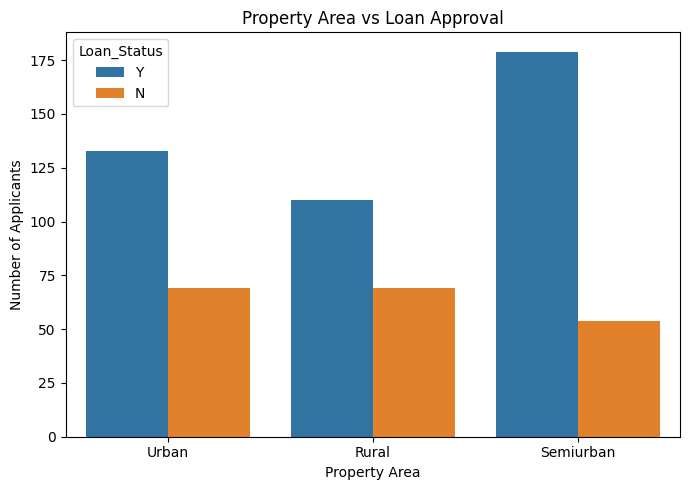


------------Gender vs loan status--------------
Loan_Status    N    Y
Gender               
Female        37   75
Male         150  339

Loan Approval Percentage by Gender:
Loan_Status      N      Y
Gender                   
Female       33.04  66.96
Male         30.67  69.33


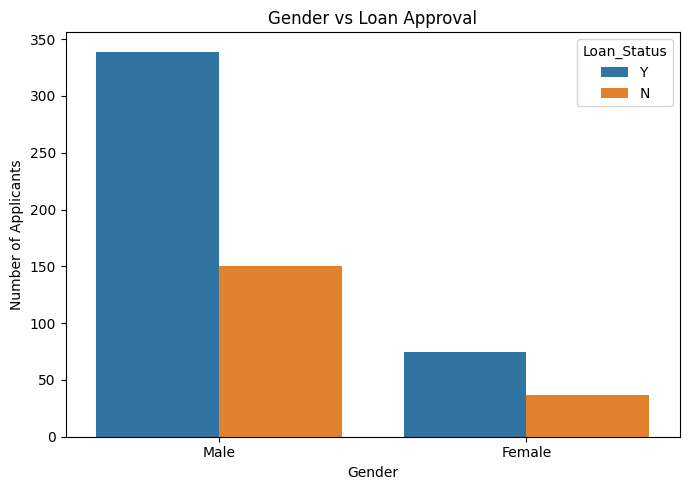

In [8]:
print("\n----------- property area vs loan status-----------------")
print(
    pd.crosstab(
        df["Property_Area"],
        df["Loan_Status"]
    )
)
print("\nLoan Approval Percentage by Property Area:")
print(
    pd.crosstab(
        df["Property_Area"],
        df["Loan_Status"],
        normalize="index"
    ).mul(100).round(2)
)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status"
)

plt.title("Property Area vs Loan Approval")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()
print("\n------------Gender vs loan status--------------")
print(
    pd.crosstab(
        df["Gender"],
        df["Loan_Status"]
    )
)
print("\nLoan Approval Percentage by Gender:")
print(
    pd.crosstab(
        df["Gender"],
        df["Loan_Status"],
        normalize="index"
    ).mul(100).round(2)
)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Loan_Status"
)

plt.title("Gender vs Loan Approval")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()


----------------married vs loan status------------------
Loan_Status    N    Y
Married              
No            79  134
Yes          113  285

Loan Approval Percentage by Marital Status:
Loan_Status      N      Y
Married                  
No           37.09  62.91
Yes          28.39  71.61


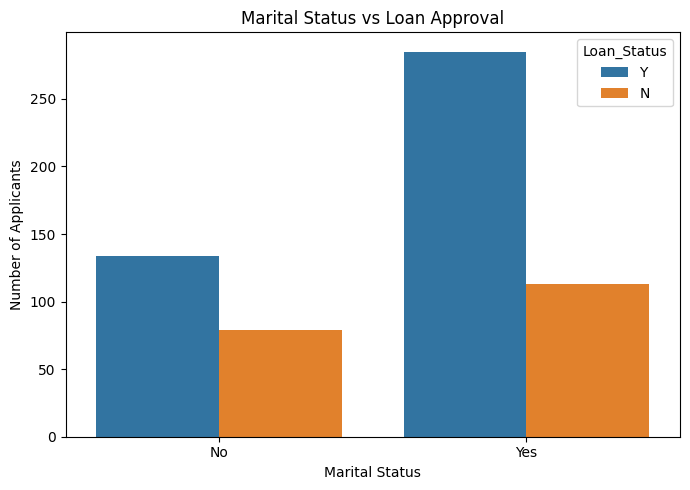


========== DEPENDENTS VS LOAN STATUS ==========
Loan_Status    N    Y
Dependents           
0            107  238
1             36   66
2             25   76
3+            18   33

Loan Approval Percentage by Dependents:
Loan_Status      N      Y
Dependents               
0            31.01  68.99
1            35.29  64.71
2            24.75  75.25
3+           35.29  64.71


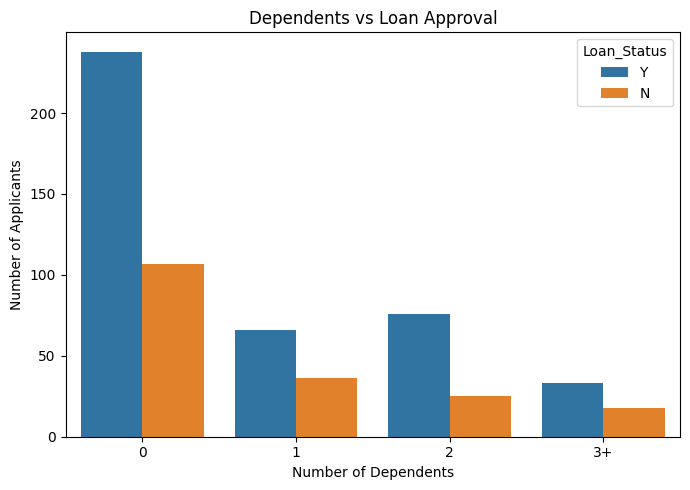


Dependents including missing values:
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64


In [9]:
print("\n----------------married vs loan status------------------")
print(
    pd.crosstab(
        df["Married"],
        df["Loan_Status"]
    )
)
print("\nLoan Approval Percentage by Marital Status:")
print(
    pd.crosstab(
        df["Married"],
        df["Loan_Status"],
        normalize="index"
    ).mul(100).round(2)
)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Married",
    hue="Loan_Status"
)

plt.title("Marital Status vs Loan Approval")
plt.xlabel("Marital Status")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()
print("\n========== DEPENDENTS VS LOAN STATUS ==========")

print(
    pd.crosstab(
        df["Dependents"],
        df["Loan_Status"]
    )
)

print("\nLoan Approval Percentage by Dependents:")

print(
    pd.crosstab(
        df["Dependents"],
        df["Loan_Status"],
        normalize="index"
    ).mul(100).round(2)
)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Loan_Status"
)

plt.title("Dependents vs Loan Approval")
plt.xlabel("Number of Dependents")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()
print("\nDependents including missing values:")
print(df["Dependents"].value_counts(dropna=False))


========== SELF EMPLOYED VS LOAN STATUS ==========
Loan_Status      N    Y
Self_Employed          
No             157  343
Yes             26   56

Loan Approval Percentage by Self Employment:
Loan_Status        N      Y
Self_Employed              
No             31.40  68.60
Yes            31.71  68.29


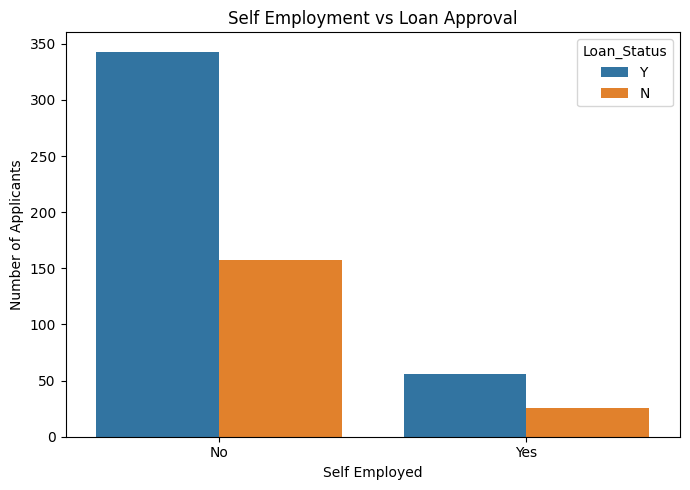


========== APPLICANT INCOME VS LOAN STATUS ==========
             count         mean          std    min     25%     50%      75%  \
Loan_Status                                                                    
N            192.0  5446.078125  6819.558528  150.0  2885.0  3833.5  5861.25   
Y            422.0  5384.068720  5765.441615  210.0  2877.5  3812.5  5771.50   

                 max  
Loan_Status           
N            81000.0  
Y            63337.0  


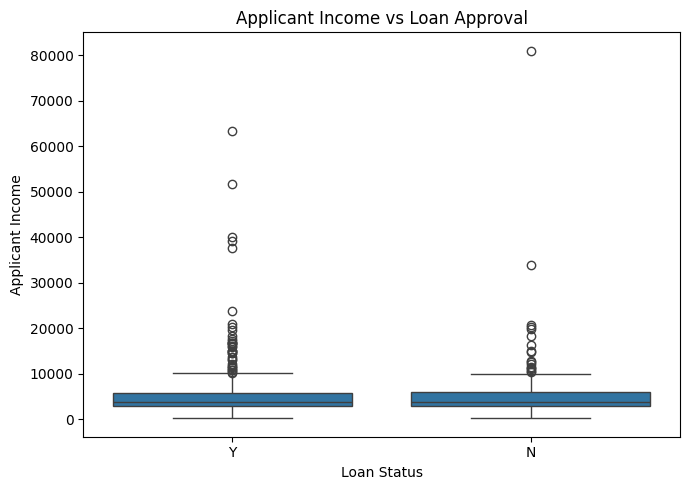


========== COAPPLICANT INCOME VS LOAN STATUS ==========
             count         mean          std  min  25%     50%      75%  \
Loan_Status                                                               
N            192.0  1877.807292  4384.060103  0.0  0.0   268.0  2273.75   
Y            422.0  1504.516398  1924.754855  0.0  0.0  1239.5  2297.25   

                 max  
Loan_Status           
N            41667.0  
Y            20000.0  


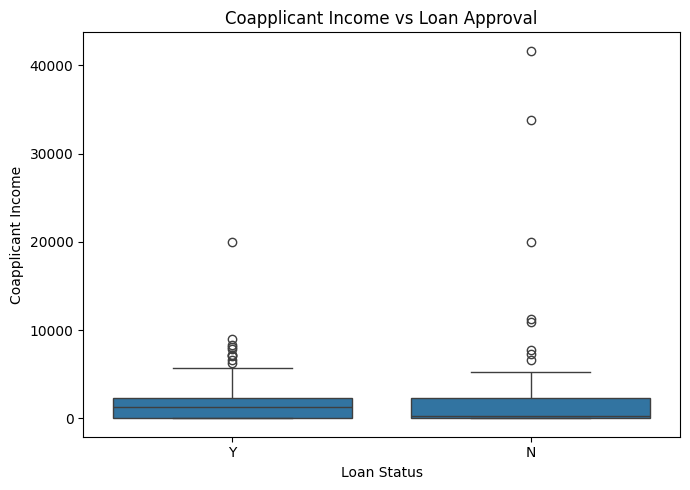


========== LOAN AMOUNT VS LOAN STATUS ==========
             count        mean        std   min    25%    50%    75%    max
Loan_Status                                                                
N            181.0  151.220994  85.862783   9.0  100.0  129.0  176.0  570.0
Y            411.0  144.294404  85.484607  17.0  100.0  126.0  161.0  700.0


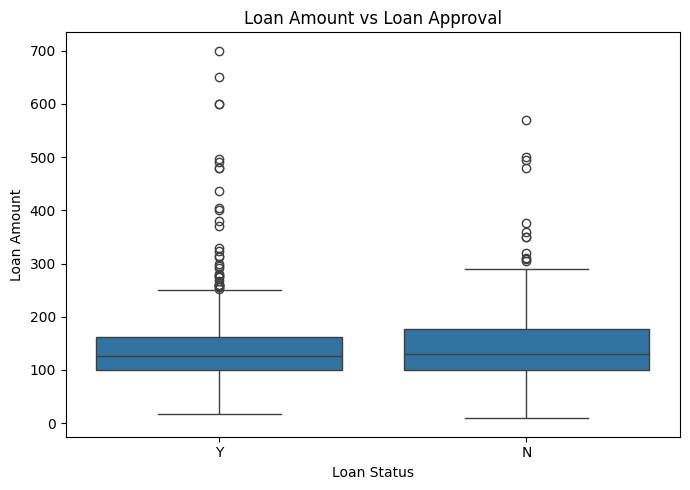

In [10]:
print("\n========== SELF EMPLOYED VS LOAN STATUS ==========")

print(
    pd.crosstab(
        df["Self_Employed"],
        df["Loan_Status"]
    )
)

print("\nLoan Approval Percentage by Self Employment:")

print(
    pd.crosstab(
        df["Self_Employed"],
        df["Loan_Status"],
        normalize="index"
    ).mul(100).round(2)
)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Self_Employed",
    hue="Loan_Status"
)

plt.title("Self Employment vs Loan Approval")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()
print("\n========== APPLICANT INCOME VS LOAN STATUS ==========")

print(
    df.groupby("Loan_Status")["ApplicantIncome"].describe()
)
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="ApplicantIncome"
)

plt.title("Applicant Income vs Loan Approval")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")

plt.tight_layout()
plt.show()
print("\n========== COAPPLICANT INCOME VS LOAN STATUS ==========")

print(
    df.groupby("Loan_Status")["CoapplicantIncome"].describe()
)
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="CoapplicantIncome"
)

plt.title("Coapplicant Income vs Loan Approval")
plt.xlabel("Loan Status")
plt.ylabel("Coapplicant Income")

plt.tight_layout()
plt.show()
print("\n========== LOAN AMOUNT VS LOAN STATUS ==========")

print(
    df.groupby("Loan_Status")["LoanAmount"].describe()
)
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="LoanAmount"
)

plt.title("Loan Amount vs Loan Approval")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.tight_layout()
plt.show()


========== OUTLIER ANALYSIS ==========

ApplicantIncome
Q1: 2877.5
Q3: 5795.0
IQR: 2917.5
Lower Bound: -1498.75
Upper Bound: 10171.25
Number of Outliers: 50

CoapplicantIncome
Q1: 0.0
Q3: 2297.25
IQR: 2297.25
Lower Bound: -3445.875
Upper Bound: 5743.125
Number of Outliers: 18

LoanAmount
Q1: 100.0
Q3: 168.0
IQR: 68.0
Lower Bound: -2.0
Upper Bound: 270.0
Number of Outliers: 39

========== CORRELATION ANALYSIS ==========
                   ApplicantIncome  CoapplicantIncome  LoanAmount  \
ApplicantIncome           1.000000          -0.116605    0.570909   
CoapplicantIncome        -0.116605           1.000000    0.188619   
LoanAmount                0.570909           0.188619    1.000000   
Loan_Amount_Term         -0.045306          -0.059878    0.039447   
Credit_History           -0.014715          -0.002056   -0.008433   

                   Loan_Amount_Term  Credit_History  
ApplicantIncome           -0.045306       -0.014715  
CoapplicantIncome         -0.059878       -0.002056  

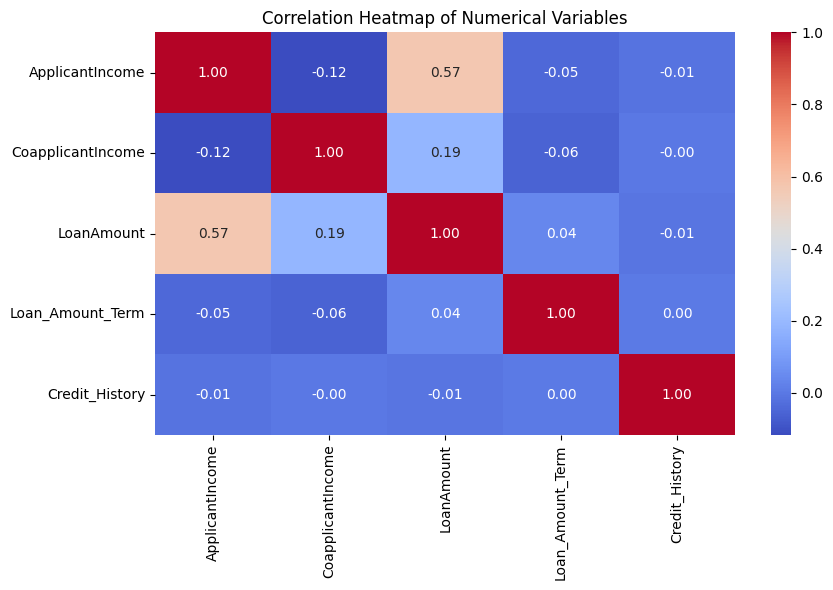


========== FINAL MISSING VALUE SUMMARY ==========
                   Missing Count  Missing Percentage
Loan_ID                        0                0.00
Gender                        13                2.12
Married                        3                0.49
Dependents                    15                2.44
Education                      0                0.00
Self_Employed                 32                5.21
ApplicantIncome                0                0.00
CoapplicantIncome              0                0.00
LoanAmount                    22                3.58
Loan_Amount_Term              14                2.28
Credit_History                50                8.14
Property_Area                  0                0.00
Loan_Status                    0                0.00


In [11]:
print("\n========== OUTLIER ANALYSIS ==========")

numerical_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
print("\n========== CORRELATION ANALYSIS ==========")

numeric_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix)
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

print("\n========== FINAL MISSING VALUE SUMMARY ==========")

missing = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

print(missing_summary)